# Phase 1 KNN Experiment Analysis

## Objective
Compare Flatten, PCA, and HOG feature representations for binary MNIST classification with KNN.

## What This Notebook Shows
- dataset loading and binary filtering
- class balance and sample inspection
- preprocessing and split strategy
- feature-mode comparison with KNN
- tuning curves, confusion matrices, and error analysis
- final best configuration shown directly in notebook outputs

In [ ]:
import importlib
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import src.features.mnist_features as mnist_features_module
mnist_features_module = importlib.reload(mnist_features_module)

from src.analysis.knn_analysis import (
    plot_knn_confusion_matrices,
    plot_knn_feature_comparison,
    plot_knn_tuning_curves,
    show_top_config,
    summarize_knn_results,
)
from src.features.mnist_features import (
    balance_binary_classes,
    build_features,
    class_distribution,
    extract_flatten_features,
    load_mnist,
    normalize_data,
    select_binary_classes,
    split_data,
)

import src.tests.evaluations as eval_module
eval_module = importlib.reload(eval_module)

import src.models.knn_model as knn_model_module
knn_model_module = importlib.reload(knn_model_module)

import src.tests.tests as test_module
test_module = importlib.reload(test_module)

CustomKNNClassifier = knn_model_module.CustomKNNClassifier
tune_k = knn_model_module.tune_k
evaluate_knn_model = knn_model_module.evaluate_model
average_precision_binary = eval_module.average_precision_binary
auc_trapezoid = eval_module.auc_trapezoid
confusion_matrix_from_predictions = eval_module.confusion_matrix_from_predictions
precision_recall_curve_binary = eval_module.precision_recall_curve_binary
roc_curve_binary = eval_module.roc_curve_binary

run_experiment_output_checks = test_module.run_experiment_output_checks
run_feature_pipeline_checks = test_module.run_feature_pipeline_checks
run_knn_specific_checks = test_module.run_knn_specific_checks

sns.set_theme(style="whitegrid")

In [37]:
# Explicit experiment config
RANDOM_STATE = 42
DATA_PATH = project_root / "data" / "mnist.npz"

CLASS_A = 0
CLASS_B = 1
TEST_SIZE = 0.2
VAL_SIZE = 0.2

# Optional class-imbalance handling (applied on train split only).
APPLY_CLASS_BALANCING = True
BALANCE_METHOD = "undersample"  # undersample | oversample

FEATURES = ["flatten", "pca", "hog"]
K_VALUES = [1, 3, 5, 7, 9]

print("RANDOM_STATE:", RANDOM_STATE)
print("CLASSES:", (CLASS_A, CLASS_B))
print("FEATURES:", FEATURES)
print("K_VALUES:", K_VALUES)
print("DATA_PATH:", DATA_PATH)
print("APPLY_CLASS_BALANCING:", APPLY_CLASS_BALANCING)
print("BALANCE_METHOD:", BALANCE_METHOD)

RANDOM_STATE: 42
CLASSES: (0, 1)
FEATURES: ['flatten', 'pca', 'hog']
K_VALUES: [1, 3, 5, 7, 9]
DATA_PATH: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification\data\mnist.npz
APPLY_CLASS_BALANCING: True
BALANCE_METHOD: undersample


## 2) Load Dataset and Configure the Experiment

This cell defines the data path, classes, split ratios, feature modes, and output folder used in the experiment.

In [38]:
t_start = perf_counter()

x_all, y_all = load_mnist(DATA_PATH)
x_binary, y_binary = select_binary_classes(x_all, y_all, CLASS_A, CLASS_B)

counts_all = class_distribution(y_binary)
print("Binary class counts (all):", counts_all)

x_train, y_train, x_val, y_val, x_test, y_test = split_data(
    x_binary,
    y_binary,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)

if APPLY_CLASS_BALANCING:
    x_train, y_train = balance_binary_classes(
        x_train,
        y_train,
        method=BALANCE_METHOD,
        random_state=RANDOM_STATE,
    )
    print("Applied class balancing on train split.")

counts_train = class_distribution(y_train)
counts_val = class_distribution(y_val)
counts_test = class_distribution(y_test)

x_train = normalize_data(x_train)
x_val = normalize_data(x_val)
x_test = normalize_data(x_test)

t_prep = perf_counter()
timing_rows = [
    {
        "stage": "data_preprocessing",
        "feature_mode": "all",
        "seconds": float(t_prep - t_start),
    }
]

print("Train/Val/Test:", x_train.shape[0], x_val.shape[0], x_test.shape[0])
print("Train counts:", counts_train)
print("Val counts:", counts_val)
print("Test counts:", counts_test)

Binary class counts (all): {0: 6903, 1: 7877}
Applied class balancing on train split.
Train/Val/Test: 8210 2956 2956
Train counts: {0: 4105, 1: 4105}
Val counts: {0: 1396, 1: 1560}
Test counts: {0: 1402, 1: 1554}


## 3) Load and Preprocess the Data

Normalization matters here because KNN is distance-based, so raw pixel ranges would distort similarity calculations.

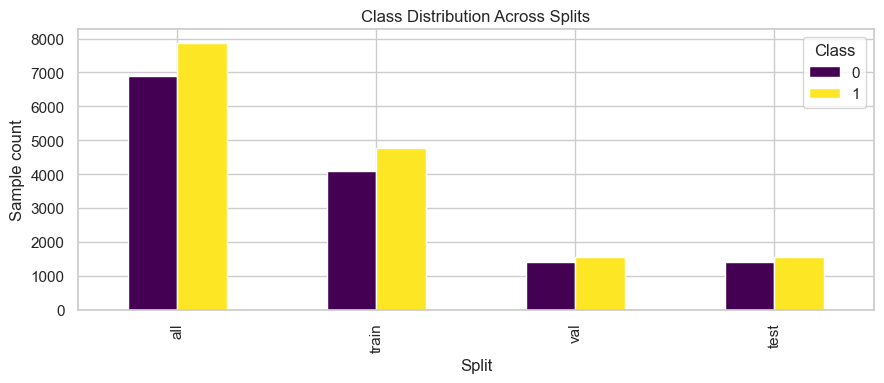

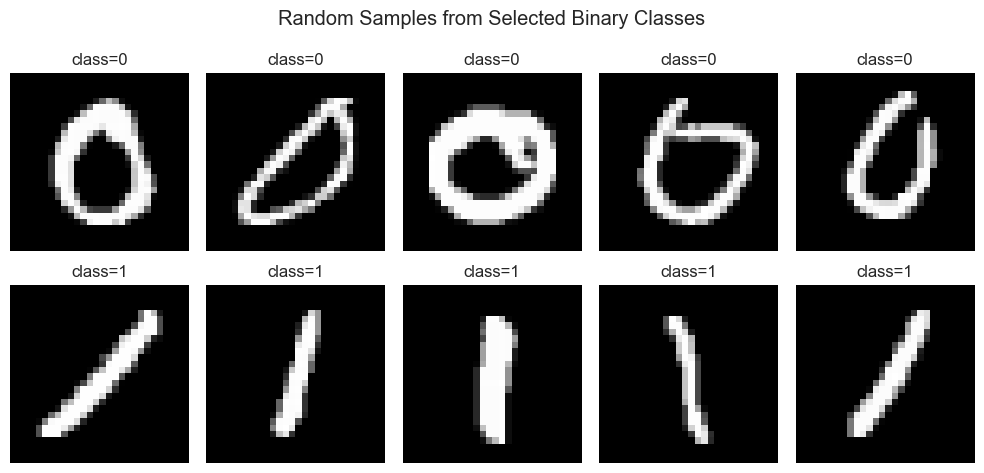

In [24]:
# Visualization checkpoint 1: class balance + sample images
split_df = pd.DataFrame(
    {
        'all': [counts_all.get(CLASS_A, 0), counts_all.get(CLASS_B, 0)],
        'train': [counts_train.get(CLASS_A, 0), counts_train.get(CLASS_B, 0)],
        'val': [counts_val.get(CLASS_A, 0), counts_val.get(CLASS_B, 0)],
        'test': [counts_test.get(CLASS_A, 0), counts_test.get(CLASS_B, 0)],
    },
    index=[CLASS_A, CLASS_B],
)

ax = split_df.T.plot(kind='bar', figsize=(9, 4), colormap='viridis')
ax.set_title('Class Distribution Across Splits')
ax.set_xlabel('Split')
ax.set_ylabel('Sample count')
ax.legend(title='Class')
plt.tight_layout()
plt.show()

rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for row, cls in enumerate([CLASS_A, CLASS_B]):
    cls_idx = np.where(y_binary == cls)[0]
    selected = rng.choice(cls_idx, size=5, replace=False)
    for col, idx in enumerate(selected):
        axes[row, col].imshow(x_binary[idx], cmap='gray')
        axes[row, col].set_title(f'class={cls}')
        axes[row, col].axis('off')

plt.suptitle('Random Samples from Selected Binary Classes')
plt.tight_layout()
plt.show()

### Dataset Exploration

The class bar chart shows whether the binary split is balanced, and the sample images confirm that the selected digits still look visually distinct after filtering.

In [39]:
experiment_results = []
tuning_tables = {}

for mode in FEATURES:
    print(f"Running KNN with feature={mode}")
    mode_start = perf_counter()

    feat_train, feat_val, feat_test = build_features(
        mode=mode,
        x_train=x_train,
        x_val=x_val,
        x_test=x_test,
)
    t_features = perf_counter()

    best_k, tuning_table = tune_k(
        x_train=feat_train,
        y_train=y_train,
        x_val=feat_val,
        y_val=y_val,
        k_values=K_VALUES,
)
    t_tune = perf_counter()

    model = CustomKNNClassifier(n_neighbors=best_k)
    model.fit(feat_train, y_train)
    metrics = evaluate_knn_model(model, feat_test, y_test, labels=[CLASS_A, CLASS_B])
    t_eval = perf_counter()

    result = {
        "feature_mode": mode,
        "best_k": int(best_k),
        "class_a": int(CLASS_A),
        "class_b": int(CLASS_B),
        "train_samples": int(len(y_train)),
        "val_samples": int(len(y_val)),
        "test_samples": int(len(y_test)),
        **metrics,
        "timing_seconds": {
            "feature_build": float(t_features - mode_start),
            "tuning": float(t_tune - t_features),
            "fit_eval": float(t_eval - t_tune),
            "total": float(t_eval - mode_start),
        },
    }

    experiment_results.append(result)
    tuning_tables[mode] = tuning_table.copy()

    for stage in ["feature_build", "tuning", "fit_eval", "total"]:
        timing_rows.append(
            {
                "stage": stage,
                "feature_mode": mode,
                "seconds": float(result["timing_seconds"].get(stage, 0.0)),
            }
        )

summary_df = summarize_knn_results(
    experiment_results,
    sort_by="test_f1_macro",
    ascending=False,
)
summary_df

Running KNN with feature=flatten
Running KNN with feature=pca
Running KNN with feature=hog


,feature_mode,best_k,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,confusion_matrix,train_samples,val_samples,test_samples
0,flatten,9,0.996617,0.996608,0.996608,0.996608,"[[1397, 5], [5, 1549]]",8210,2956,2956
1,hog,9,0.994587,0.994401,0.994782,0.994575,"[[1400, 2], [14, 1540]]",8210,2956,2956
2,pca,1,0.992896,0.993333,0.992511,0.992871,"[[1381, 21], [0, 1554]]",8210,2956,2956


## 4) Experiment Setup + Core Equations

We test three feature representations with the same split, the same random state, and the same KNN search space so the comparison stays fair.

- Feature modes: Flatten, PCA, HOG
- Model: KNN (implemented from scratch with NumPy)
- Hyperparameters: k in {1, 3, 5, 7, 9}
- Selection rule: highest validation F1, then accuracy

### Equations used in this notebook

1. Flatten feature

$$
\mathbf{x}_{flat} = \mathrm{vec}(I) \in \mathbb{R}^{H\cdot W}
$$

2. PCA

$$
\mathbf{X}_c = \mathbf{X} - \bar{\mathbf{X}},\quad \mathbf{X}_c = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^T
$$

$$
\mathbf{Z} = \mathbf{X}_c\mathbf{V}_{1:d}^T
$$

3. HOG

$$
m(x,y)=\sqrt{g_x(x,y)^2 + g_y(x,y)^2},\quad \theta(x,y)=\operatorname{atan2}(g_y,g_x)\;\;\text{(mapped to }[0,180)\text{)}
$$

Cell histograms are built over orientation bins, then block-normalized with L2-Hys.

$$
\mathbf{h}_{norm}=\frac{\mathbf{h}}{\sqrt{\|\mathbf{h}\|_2^2+\varepsilon^2}},\quad \mathbf{h}_{clip}=\min(\mathbf{h}_{norm},0.2)
$$

4. KNN prediction

$$
d(\mathbf{x},\mathbf{x}_i)=\|\mathbf{x}-\mathbf{x}_i\|_2
$$

$$
\hat{y}=\arg\max_c\sum_{i\in \mathcal{N}_k(\mathbf{x})}\mathbf{1}[y_i=c]
$$

5. Metrics (manual)

For each class:

$$
\mathrm{Precision}=\frac{TP}{TP+FP},\quad \mathrm{Recall}=\frac{TP}{TP+FN},\quad F1=\frac{2PR}{P+R}
$$

Macro averages are arithmetic means across classes; accuracy is:

$$
\mathrm{Accuracy}=\frac{\sum_i C_{ii}}{\sum_{i,j} C_{ij}}
$$

## 4.1) Running Experiments

This loop evaluates every feature representation on the same split and with the same K values so the comparison stays fair.

## 4.2) Cluster Separation (2D PCA View)

This plot projects the normalized training images into 2 dimensions using PCA, so you can visually inspect how well the two classes separate in feature space.

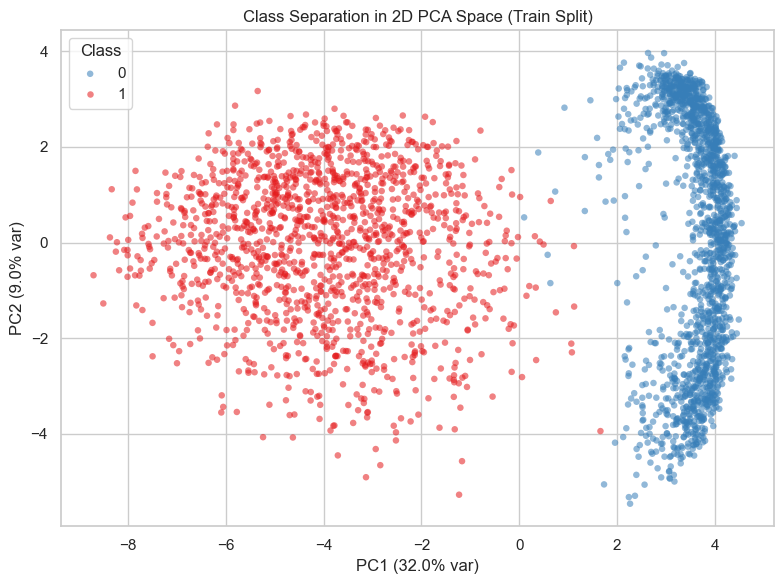

In [ ]:
# Cluster-separation view: 2D projection of normalized training images using NumPy PCA
x_train_flat_vis = extract_flatten_features(x_train)

# Use at most 3000 samples for faster plotting while keeping class balance meaningful
max_vis_samples = min(3000, x_train_flat_vis.shape[0])
rng_vis = np.random.default_rng(RANDOM_STATE)
vis_idx = rng_vis.choice(x_train_flat_vis.shape[0], size=max_vis_samples, replace=False)

x_vis = x_train_flat_vis[vis_idx]
y_vis = y_train[vis_idx]

# PCA from scratch with SVD: center then project to first two principal directions
x_vis_centered = x_vis - np.mean(x_vis, axis=0, keepdims=True)
_, singular_values_vis, vh_vis = np.linalg.svd(x_vis_centered, full_matrices=False)
components_2d = vh_vis[:2]
x_vis_2d = x_vis_centered @ components_2d.T

var_all = singular_values_vis * singular_values_vis
var_ratio = var_all / np.sum(var_all)

plot_df = pd.DataFrame({
    'PC1': x_vis_2d[:, 0],
    'PC2': x_vis_2d[:, 1],
    'label': y_vis,
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='label',
    palette='Set1',
    alpha=0.55,
    s=22,
    linewidth=0,
    ax=ax,
)
ax.set_title('Class Separation in 2D PCA Space (Train Split)')
ax.set_xlabel(f'PC1 ({var_ratio[0] * 100:.1f}% var)')
ax.set_ylabel(f'PC2 ({var_ratio[1] * 100:.1f}% var)')
ax.legend(title='Class', labels=[str(CLASS_A), str(CLASS_B)])
plt.tight_layout()
plt.show()

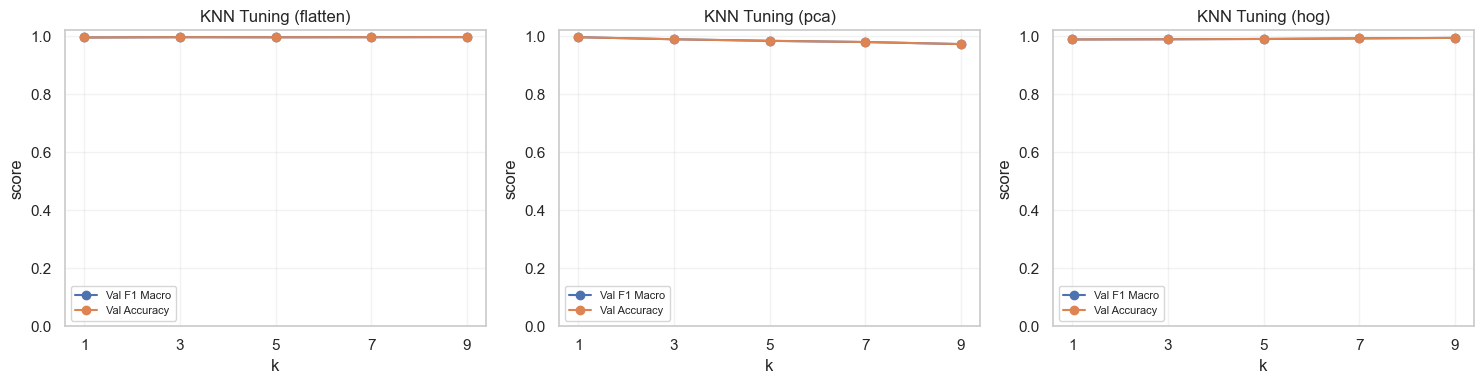

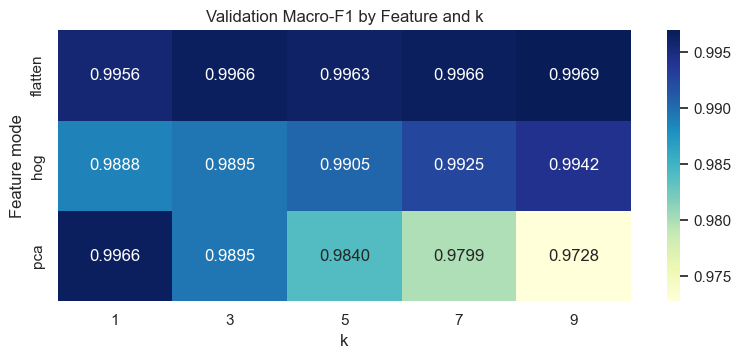

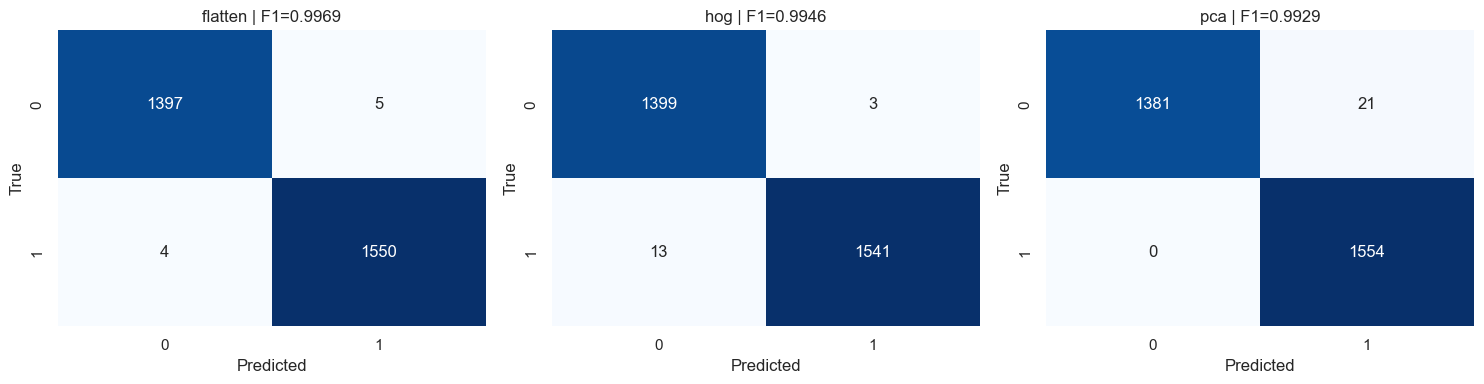

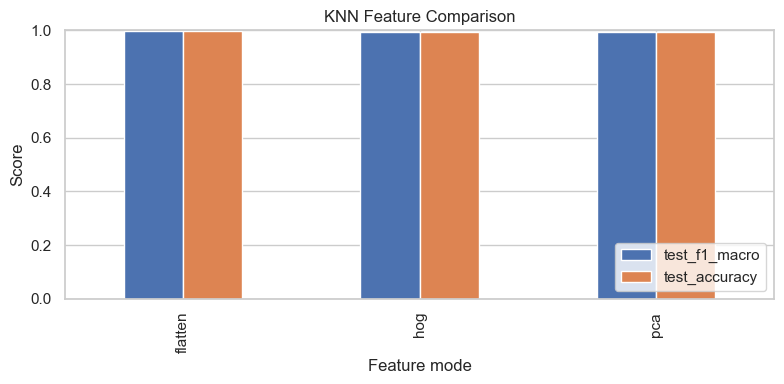

In [ ]:
# Visualization checkpoint 2: k-wise curves + confusion matrices + feature comparison
fig_tune, _ = plot_knn_tuning_curves(
    tuning_tables=tuning_tables,
    feature_modes=FEATURES,
    score_columns=["val_f1_macro", "val_accuracy"],
)
plt.show()

# Compact view: validation macro-F1 across all features and k values.
heatmap_rows = []
for mode in FEATURES:
    tune_df = tuning_tables[mode].sort_values("k")
    for _, row in tune_df.iterrows():
        heatmap_rows.append(
            {
                "feature_mode": mode,
                "k": int(row["k"]),
                "val_f1_macro": float(row["val_f1_macro"]),
            }
        )

k_heatmap_df = pd.DataFrame(heatmap_rows).pivot(index="feature_mode", columns="k", values="val_f1_macro")
fig, ax = plt.subplots(figsize=(8, 2.7 + 0.35 * len(FEATURES)))
sns.heatmap(k_heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu", cbar=True, ax=ax)
ax.set_title("Validation Macro-F1 by Feature and k")
ax.set_xlabel("k")
ax.set_ylabel("Feature mode")
plt.tight_layout()
plt.show()

fig_cm, _ = plot_knn_confusion_matrices(
    summary_df=summary_df,
    class_a=CLASS_A,
    class_b=CLASS_B,
)
plt.show()

fig_comp, _ = plot_knn_feature_comparison(
    summary_df=summary_df,
    metric_columns=["test_f1_macro", "test_accuracy"],
)
plt.show()

## 4.1) Test Checks Dashboard

This section uses the reusable checks from `src.tests.tests` to validate:
- feature pipeline shape/finite-value invariants
- KNN tuning and prediction behavior
- final experiment output schema/ranges

The dashboard shows pass rates per feature mode and category, plus a table of failed checks (if any).

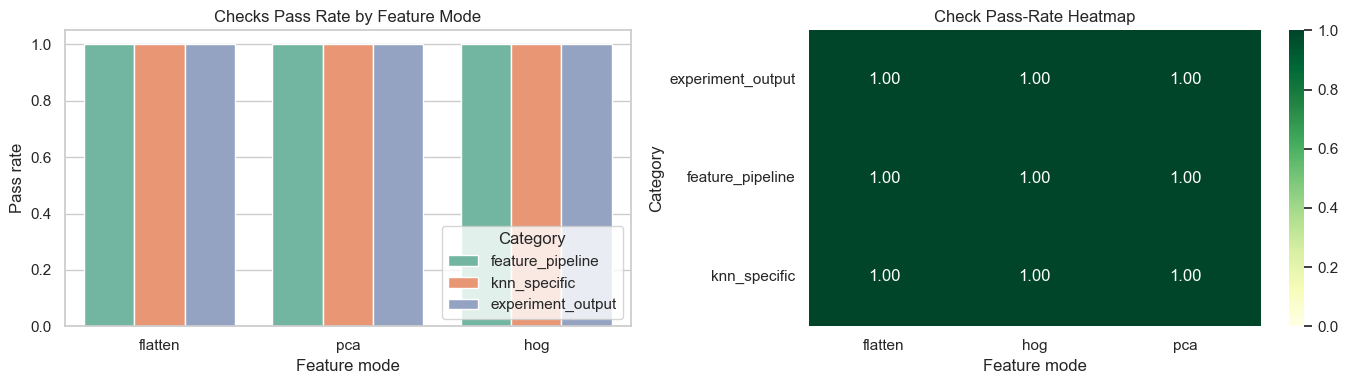

,feature_mode,category,passed,total,pass_rate
0,flatten,experiment_output,18,18,1.0
1,flatten,feature_pipeline,10,10,1.0
2,flatten,knn_specific,5,5,1.0
3,hog,experiment_output,18,18,1.0
4,hog,feature_pipeline,10,10,1.0
5,hog,knn_specific,5,5,1.0
6,pca,experiment_output,18,18,1.0
7,pca,feature_pipeline,10,10,1.0
8,pca,knn_specific,5,5,1.0


All checks passed across all feature modes.


In [34]:
check_summary_rows = []
check_failure_rows = []

for mode in FEATURES:
    feat_check = run_feature_pipeline_checks(
        x_train=x_train,
        x_val=x_val,
        x_test=x_test,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        feature_mode=mode,
        pca_components=0.95,
        random_state=RANDOM_STATE,
    )

    feat_train_tmp, feat_val_tmp, feat_test_tmp = build_features(
        mode=mode,
        x_train=x_train,
        x_val=x_val,
        x_test=x_test,
    )
    knn_check = run_knn_specific_checks(
        x_train=feat_train_tmp,
        y_train=y_train,
        x_eval=feat_val_tmp,
        y_eval=y_val,
        labels=[CLASS_A, CLASS_B],
        k_values=K_VALUES,
    )

    mode_result = next(item for item in experiment_results if item["feature_mode"] == mode)
    out_check = run_experiment_output_checks(mode_result, expected_labels_count=2)

    grouped = {
        "feature_pipeline": feat_check,
        "knn_specific": knn_check,
        "experiment_output": out_check,
    }

    for category, report in grouped.items():
        passed_count = int(sum(1 for c in report["checks"] if c["passed"]))
        total_count = int(len(report["checks"]))
        pass_rate = passed_count / max(total_count, 1)
        check_summary_rows.append(
            {
                "feature_mode": mode,
                "category": category,
                "passed": passed_count,
                "total": total_count,
                "pass_rate": pass_rate,
            }
        )

        for c in report["checks"]:
            if not c["passed"]:
                check_failure_rows.append(
                    {
                        "feature_mode": mode,
                        "category": category,
                        "check": c["name"],
                        "details": c.get("details", ""),
                    }
                )

checks_df = pd.DataFrame(check_summary_rows)
failures_df = pd.DataFrame(check_failure_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(
    data=checks_df,
    x="feature_mode",
    y="pass_rate",
    hue="category",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Checks Pass Rate by Feature Mode")
axes[0].set_ylabel("Pass rate")
axes[0].set_xlabel("Feature mode")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Category", loc="lower right")

pivot_checks = checks_df.pivot(index="category", columns="feature_mode", values="pass_rate")
sns.heatmap(
    pivot_checks,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    vmin=0,
    vmax=1,
    cbar=True,
    ax=axes[1],
)
axes[1].set_title("Check Pass-Rate Heatmap")
axes[1].set_xlabel("Feature mode")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()

display(checks_df.sort_values(["feature_mode", "category"]).reset_index(drop=True))

if failures_df.empty:
    print("All checks passed across all feature modes.")
else:
    print("Failed checks:")
    display(failures_df.reset_index(drop=True))

## 4.2) Validation/Test Loss Curves (Overfit Check)

For KNN, we track classification loss as `1 - accuracy` across `k` for both validation and test splits.
- If validation loss is low but test loss is much higher, the model is overfitting.
- If both losses are high, the model is underfitting.
- A stable model has low validation and test loss with a small gap.

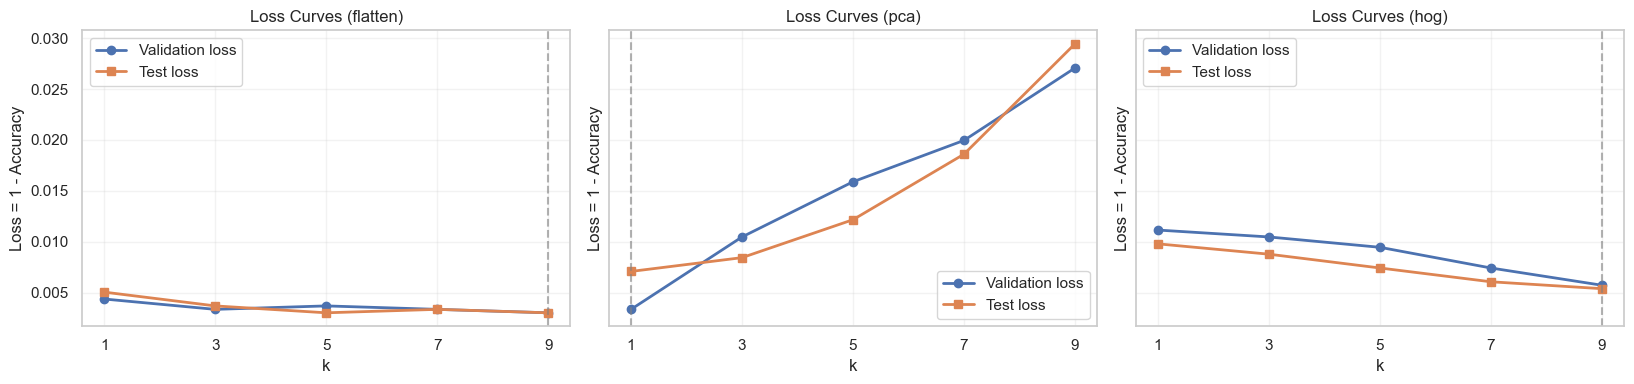

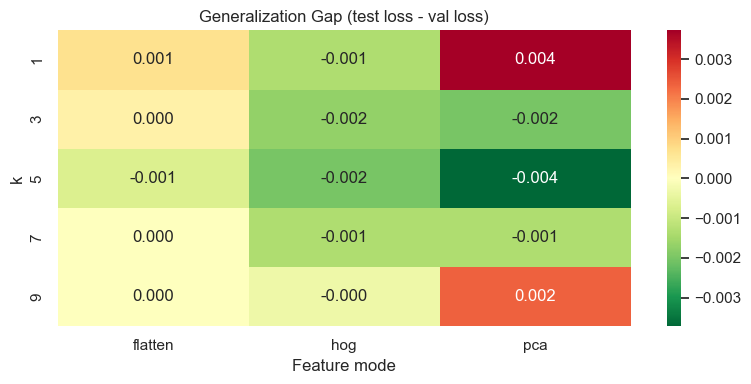

Recommended k from loss analysis:
{'feature_mode': 'flatten', 'k': 9, 'val_loss': 0.003, 'test_loss': 0.003, 'generalization_gap': 0.0, 'diagnosis': 'Reasonably balanced fit (small validation-test loss gap).'}


,feature_mode,k,val_accuracy,test_accuracy,val_loss,test_loss,generalization_gap
0,flatten,1,0.995602,0.994926,0.004398,0.005074,0.000677
1,flatten,3,0.996617,0.996279,0.003383,0.003721,0.000338
2,flatten,5,0.996279,0.996955,0.003721,0.003045,-0.000677
3,flatten,7,0.996617,0.996617,0.003383,0.003383,0.000000
4,flatten,9,0.996955,0.996955,0.003045,0.003045,0.000000
5,hog,1,0.988836,0.990189,0.011164,0.009811,-0.001353
6,hog,3,0.989513,0.991204,0.010487,0.008796,-0.001691
7,hog,5,0.990528,0.992558,0.009472,0.007442,-0.002030
8,hog,7,0.992558,0.993911,0.007442,0.006089,-0.001353
9,hog,9,0.994249,0.994587,0.005751,0.005413,-0.000338


In [35]:
loss_rows = []

for mode in FEATURES:
    feat_train_tmp, feat_val_tmp, feat_test_tmp = build_features(
        mode=mode,
        x_train=x_train,
        x_val=x_val,
        x_test=x_test,
    )

    for k in K_VALUES:
        model_k = CustomKNNClassifier(n_neighbors=int(k))
        model_k.fit(feat_train_tmp, y_train)

        y_val_pred = model_k.predict(feat_val_tmp)
        y_test_pred = model_k.predict(feat_test_tmp)

        val_acc = float(np.mean(y_val_pred == y_val))
        test_acc = float(np.mean(y_test_pred == y_test))
        val_loss = 1.0 - val_acc
        test_loss = 1.0 - test_acc
        gap = test_loss - val_loss

        loss_rows.append(
            {
                "feature_mode": mode,
                "k": int(k),
                "val_accuracy": val_acc,
                "test_accuracy": test_acc,
                "val_loss": val_loss,
                "test_loss": test_loss,
                "generalization_gap": gap,
            }
        )

loss_df = pd.DataFrame(loss_rows).sort_values(["feature_mode", "k"]).reset_index(drop=True)

fig, axes = plt.subplots(1, len(FEATURES), figsize=(5.5 * len(FEATURES), 4), sharey=True)
if len(FEATURES) == 1:
    axes = [axes]

for ax, mode in zip(axes, FEATURES):
    mode_df = loss_df[loss_df["feature_mode"] == mode].sort_values("k")
    ax.plot(mode_df["k"], mode_df["val_loss"], marker="o", lw=2, label="Validation loss")
    ax.plot(mode_df["k"], mode_df["test_loss"], marker="s", lw=2, label="Test loss")
    best_row_mode = mode_df.sort_values(["val_loss", "generalization_gap", "k"], ascending=[True, True, True]).iloc[0]
    ax.axvline(int(best_row_mode["k"]), ls="--", color="gray", alpha=0.6)
    ax.set_title(f"Loss Curves ({mode})")
    ax.set_xlabel("k")
    ax.set_ylabel("Loss = 1 - Accuracy")
    ax.set_xticks(sorted(mode_df["k"].unique()))
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

gap_pivot = loss_df.pivot(index="k", columns="feature_mode", values="generalization_gap")
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(gap_pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", center=0.0, ax=ax)
ax.set_title("Generalization Gap (test loss - val loss)")
ax.set_xlabel("Feature mode")
ax.set_ylabel("k")
plt.tight_layout()
plt.show()

best_loss_row = loss_df.sort_values(
    ["val_loss", "generalization_gap", "test_loss", "k"],
    ascending=[True, True, True, True],
).iloc[0]

best_gap = float(best_loss_row["generalization_gap"])
if best_gap > 0.02:
    fit_state = "Potential overfit (test loss is noticeably higher than validation loss)."
elif best_gap < -0.02:
    fit_state = "Potential underfit or validation noise (validation loss is higher than test loss)."
else:
    fit_state = "Reasonably balanced fit (small validation-test loss gap)."

print("Recommended k from loss analysis:")
print(
    {
        "feature_mode": best_loss_row["feature_mode"],
        "k": int(best_loss_row["k"]),
        "val_loss": round(float(best_loss_row["val_loss"]), 4),
        "test_loss": round(float(best_loss_row["test_loss"]), 4),
        "generalization_gap": round(best_gap, 4),
        "diagnosis": fit_state,
    }
)

display(loss_df)

## 5) Results

### 5.1 Tuning Curves
These plots show how each feature mode responds to different values of k. A good curve should peak clearly rather than stay flat or noisy.

### 5.2 Confusion Matrices
These matrices show which class each model confuses more often after tuning.

### 5.3 Feature Comparison
This bar chart makes the best feature representation easy to compare across test F1 and accuracy.

In [40]:
best_knn_raw = show_top_config(summary_df, metric="test_f1_macro")

best_knn = {}
for key, value in best_knn_raw.items():
    if isinstance(value, np.ndarray):
        best_knn[key] = value.tolist()
    elif np.isscalar(value) and pd.isna(value):
        best_knn[key] = None
    else:
        best_knn[key] = value

failure_df = _build_failure_summary(summary_df)
benchmark_df = pd.DataFrame(timing_rows)

def _to_jsonable_distribution(dist):
    return {str(int(k)): int(v) for k, v in dist.items()}

run_info = {
    "class_distribution_all": _to_jsonable_distribution(counts_all),
    "class_distribution_train": _to_jsonable_distribution(counts_train),
    "class_distribution_val": _to_jsonable_distribution(counts_val),
    "class_distribution_test": _to_jsonable_distribution(counts_test),
    "feature_modes": FEATURES,
    "k_values": K_VALUES,
    "test_size": TEST_SIZE,
    "val_size": VAL_SIZE,
    "class_balancing": {
        "enabled": APPLY_CLASS_BALANCING,
        "method": BALANCE_METHOD if APPLY_CLASS_BALANCING else None,
    },
    "data_path": str(DATA_PATH),
    "random_state": RANDOM_STATE,
}

print("Best configuration:", best_knn)
print("Run info:", run_info)

print("\nTiming breakdown preview:")
display(benchmark_df.head(10))

print("\nFailure analysis:")
display(failure_df)

Best configuration: {'feature_mode': 'flatten', 'best_k': 9, 'test_accuracy': 0.996617050067659, 'test_precision_macro': 0.9966080814868261, 'test_recall_macro': 0.9966080814868261, 'test_f1_macro': 0.9966080814868261, 'confusion_matrix': [[1397, 5], [5, 1549]], 'train_samples': 8210, 'val_samples': 2956, 'test_samples': 2956}
Run info: {'class_distribution_all': {'0': 6903, '1': 7877}, 'class_distribution_train': {'0': 4105, '1': 4105}, 'class_distribution_val': {'0': 1396, '1': 1560}, 'class_distribution_test': {'0': 1402, '1': 1554}, 'feature_modes': ['flatten', 'pca', 'hog'], 'k_values': [1, 3, 5, 7, 9], 'test_size': 0.2, 'val_size': 0.2, 'class_balancing': {'enabled': True, 'method': 'undersample'}, 'data_path': 'C:\\Users\\Ahmed Fahmy\\Downloads\\Projects\\ML\\Mnist-Classification\\data\\mnist.npz', 'random_state': 42}

Timing breakdown preview:


,stage,feature_mode,seconds
0,data_preprocessing,all,0.325746
1,feature_build,flatten,0.052147
2,tuning,flatten,3.808519
3,fit_eval,flatten,0.850056
4,total,flatten,4.710722
5,feature_build,pca,0.473155
6,tuning,pca,2.741798
7,fit_eval,pca,0.368094
8,total,pca,3.583047
9,feature_build,hog,10.636421



Failure analysis:


,feature_mode,best_k,false_positives,false_negatives,total_errors,error_rate
0,flatten,9,5,5,10,0.003383
1,hog,9,2,14,16,0.005413
2,pca,1,21,0,21,0.007104


## 5.4) Extra Error Analysis

This adds two visuals that help explain where the best model succeeds and fails:
- a normalized confusion matrix for the selected configuration
- a small gallery of misclassified test images with true/predicted labels

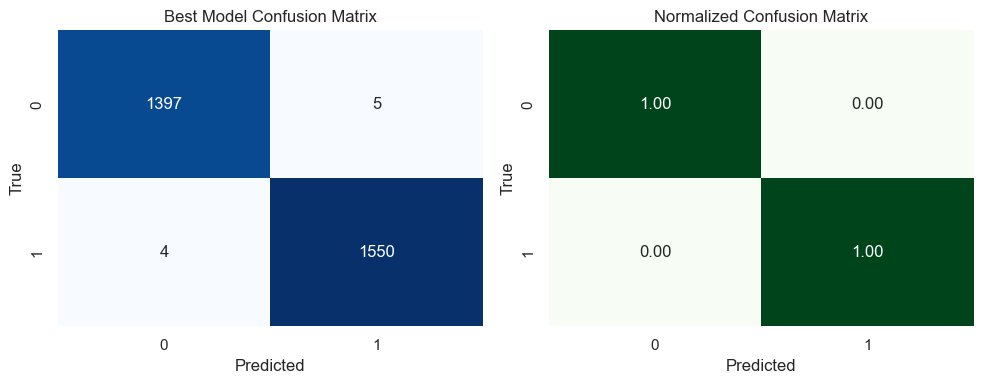

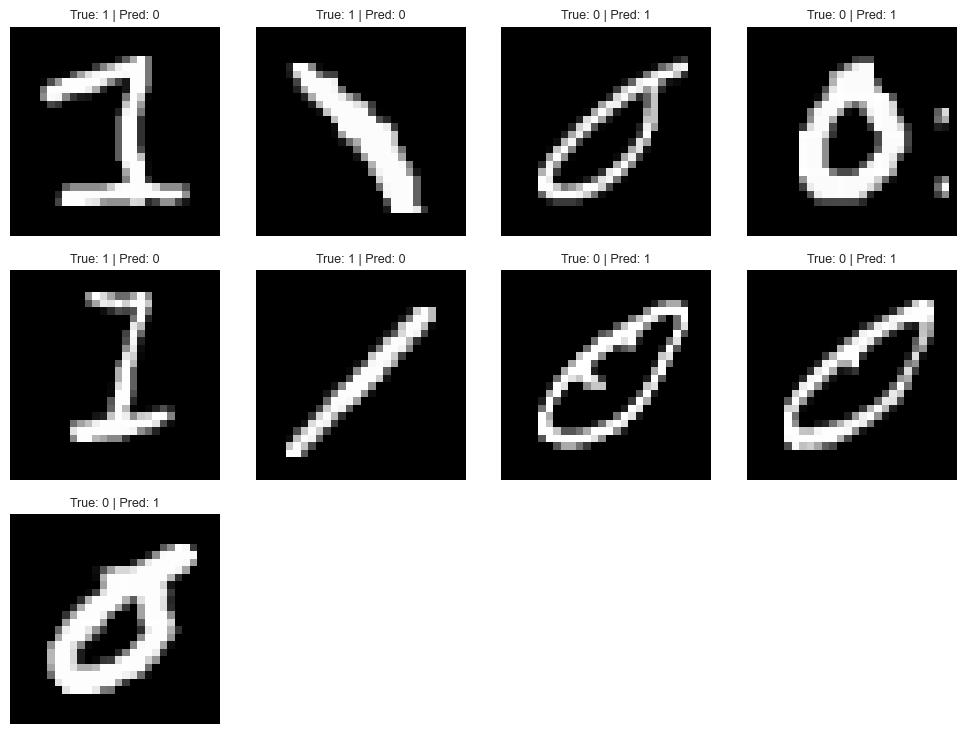

In [ ]:
best_mode = best_knn.get("feature_mode", summary_df.iloc[0]["feature_mode"]) if "best_knn" in globals() else summary_df.iloc[0]["feature_mode"]
best_k = int(best_knn.get("best_k", summary_df.iloc[0]["best_k"])) if "best_knn" in globals() else int(summary_df.iloc[0]["best_k"])

x_train_best, x_val_best, x_test_best = build_features(
    mode=best_mode,
    x_train=x_train,
    x_val=x_val,
    x_test=x_test,
)

best_model = CustomKNNClassifier(n_neighbors=best_k)
best_model.fit(x_train_best, y_train)
y_pred_best = best_model.predict(x_test_best)

cm_best = confusion_matrix_from_predictions(y_test, y_pred_best, labels=[CLASS_A, CLASS_B])
row_sums = np.sum(cm_best, axis=1, keepdims=True)
cm_best_norm = np.divide(cm_best, np.maximum(row_sums, 1), where=np.maximum(row_sums, 1) != 0)
mis_idx = np.where(y_pred_best != y_test)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0], xticklabels=[CLASS_A, CLASS_B], yticklabels=[CLASS_A, CLASS_B])
axes[0].set_title("Best Model Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_best_norm, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, cbar=False, ax=axes[1], xticklabels=[CLASS_A, CLASS_B], yticklabels=[CLASS_A, CLASS_B])
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

def plot_digit_grid(images, labels, predictions=None, max_items=16):
    count = min(max_items, len(images))
    cols = 4
    rows = int(np.ceil(count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(10, 2.5 * rows))
    axes = np.asarray(axes).ravel()
    for ax, image, true_label, pred_label in zip(axes, images[:count], labels[:count], predictions[:count] if predictions is not None else labels[:count]):
        ax.imshow(image, cmap="gray")
        if predictions is None:
            title = f"True: {true_label}"
        else:
            title = f"True: {true_label} | Pred: {pred_label}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    for ax in axes[count:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

if len(mis_idx) > 0:
    sample_mis_idx = mis_idx[:16]
    plot_digit_grid(x_test[sample_mis_idx], y_test[sample_mis_idx], y_pred_best[sample_mis_idx], max_items=16)
else:
    print("No misclassified test samples to display.")

## 5.5) Probability Tradeoff Curves

The logistic notebook’s strongest reusable idea is the tradeoff view: for models that expose probabilities, ROC and precision-recall curves show how the classifier behaves across thresholds. KNN supports `predict_proba`, so we can use the same idea here.

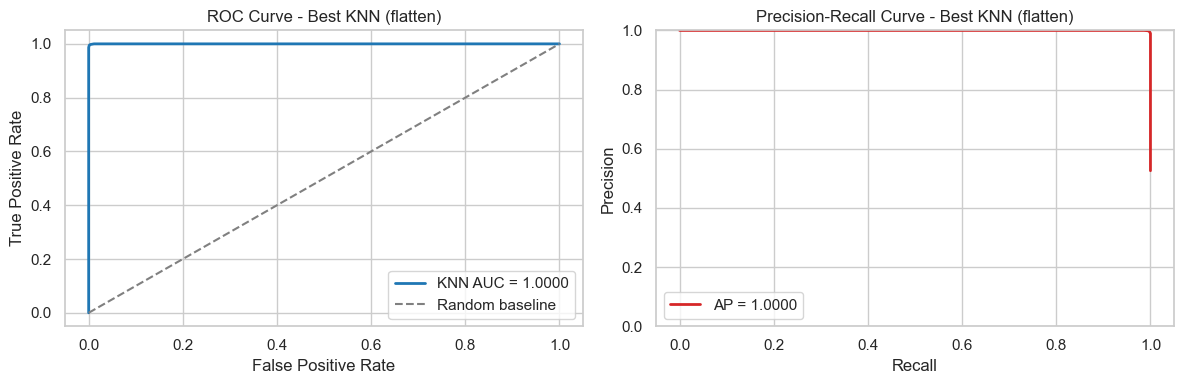

ROC AUC: 1.0
Average precision: 1.0


In [ ]:
# ROC and Precision-Recall from scratch (NumPy-based helpers)
class_to_index = {int(c): i for i, c in enumerate(best_model.classes_)}
y_proba_best = best_model.predict_proba(x_test_best)[:, class_to_index[CLASS_B]]

fpr, tpr, _ = roc_curve_binary(y_test, y_proba_best, pos_label=CLASS_B)
precisions, recalls, _ = precision_recall_curve_binary(y_test, y_proba_best, pos_label=CLASS_B)
roc_auc = auc_trapezoid(fpr, tpr)
avg_precision = average_precision_binary(y_test, y_proba_best, pos_label=CLASS_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'KNN AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
axes[0].set_title(f'ROC Curve - Best KNN ({best_mode})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].plot(recalls, precisions, color='#d62728', lw=2, label=f'AP = {avg_precision:.4f}')
axes[1].set_title(f'Precision-Recall Curve - Best KNN ({best_mode})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

print('ROC AUC:', round(float(roc_auc), 4))
print('Average precision:', round(float(avg_precision), 4))

## 6) Analysis

- PCA can reduce dimensionality and noise, but it may also remove useful digit detail.
- HOG usually performs well here because it preserves edge and stroke structure.
- Flattened pixels are the simplest representation, but KNN can struggle more with raw high-dimensional distances.
- The best configuration should be chosen from the validation-driven ranking, not from the plots alone.

## 7) Conclusion

- Best feature: see the printed `best_knn` summary below.
- Best K: taken from the top-ranked validation result.
- Key insight: the notebook compares feature representations fairly and then uses validation-driven selection to choose the best KNN setup.
